In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
test_dataset = '/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/datasets/processed_files/wolfset_test.csv'

In [ ]:
import pandas as pd
test_df = pd.read_csv(test_dataset)
test_df.head()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_rolloff,label,motor_code,transient_code,noise_code,filename
0,-0.195022,0.520307,1.045274,1.423026,-0.043421,1.638269,1.357592,0.325917,0.749180,0.011728,-1.190328,-0.418892,0.249562,-0.411805,4,20,16,0,A00020T16N00.wav
1,0.329162,1.479931,0.042357,-0.948549,-0.851235,-1.180881,-1.049700,-0.496968,0.082628,-0.084737,-0.452429,-0.751742,-0.590188,-1.175193,1,20000,0,2,A20000T00N02x05.wav
2,-0.168669,-0.150378,-0.073948,-0.572782,-1.859101,-1.035160,-0.635377,-1.170103,0.359874,1.427764,-0.412697,-0.204811,0.328098,0.107742,1,50000,0,0,A50000T00N00x01.wav
3,0.378953,-0.133878,-0.986338,-0.570448,-1.003522,0.007831,0.531099,-0.296958,-1.111736,-0.169616,-0.125024,-0.338873,-0.077006,-0.270697,1,20000,0,8,A20000T00N08x03.wav
4,0.222945,-0.443919,-1.705451,-0.484708,-0.944805,-0.861414,1.028903,1.420987,0.295695,1.788042,-0.220866,-1.597964,-0.664904,-0.515587,1,20000,0,0,A20000T00N00x01.wav


In [ ]:
columns = test_df.columns
columns

Index(['mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6',
       'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12',
       'spectral_rolloff', 'label', 'motor_code', 'transient_code',
       'noise_code', 'filename'],
      dtype='object')

In [ ]:
drop_column_list = ['motor_code', 'transient_code',
       'noise_code', 'filename']
updated_test_df = test_df.drop(drop_column_list, axis=1)
updated_test_df.head()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_rolloff,label
0,-0.195022,0.520307,1.045274,1.423026,-0.043421,1.638269,1.357592,0.325917,0.749180,0.011728,-1.190328,-0.418892,0.249562,-0.411805,4
1,0.329162,1.479931,0.042357,-0.948549,-0.851235,-1.180881,-1.049700,-0.496968,0.082628,-0.084737,-0.452429,-0.751742,-0.590188,-1.175193,1
2,-0.168669,-0.150378,-0.073948,-0.572782,-1.859101,-1.035160,-0.635377,-1.170103,0.359874,1.427764,-0.412697,-0.204811,0.328098,0.107742,1
3,0.378953,-0.133878,-0.986338,-0.570448,-1.003522,0.007831,0.531099,-0.296958,-1.111736,-0.169616,-0.125024,-0.338873,-0.077006,-0.270697,1
4,0.222945,-0.443919,-1.705451,-0.484708,-0.944805,-0.861414,1.028903,1.420987,0.295695,1.788042,-0.220866,-1.597964,-0.664904,-0.515587,1


In [ ]:
X = updated_test_df.drop('label', axis=1).values
Y = updated_test_df['label'].values

In [ ]:
import joblib
model_path = '/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/models/LogisticRegression_bestmodel.pkl'
model = joblib.load(model_path)

In [ ]:
import numpy as np
y_true = np.array(Y)
test_data_list = X
y_pred = []

for rows in test_data_list:
  prediction = model.predict(np.array([rows]))
  y_pred.append(prediction[0])



In [ ]:
y_pred

[np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(5),
 np.int64(3),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(2),
 np.int64(4),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(5),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1)]

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, text_fontsize=30, xlabel_fontsize=12, ylabel_fontsize=12, xtick_labelsize=10, ytick_labelsize=10, title_fontsize=12):
    # Compute normalized confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Convert to percentages
    cm_percentage = cm

    # Create annotations for confusion matrix values with the percentage sign
    annotations = np.array([[f'{val}' for val in row] for row in cm_percentage])

    # Plot the confusion matrix
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm_percentage, annot=annotations, fmt='', cmap="Blues",
                xticklabels=labels, yticklabels=labels, annot_kws={'fontsize': text_fontsize}, cbar=False)

    plt.title("Confusion Matrix", fontsize=title_fontsize)
    plt.ylabel('True label', fontsize=ylabel_fontsize)
    plt.xlabel('Predicted label', fontsize=xlabel_fontsize)
    plt.tick_params(axis='x', labelsize=xtick_labelsize)
    plt.tick_params(axis='y', labelsize=ytick_labelsize)
    plt.show()

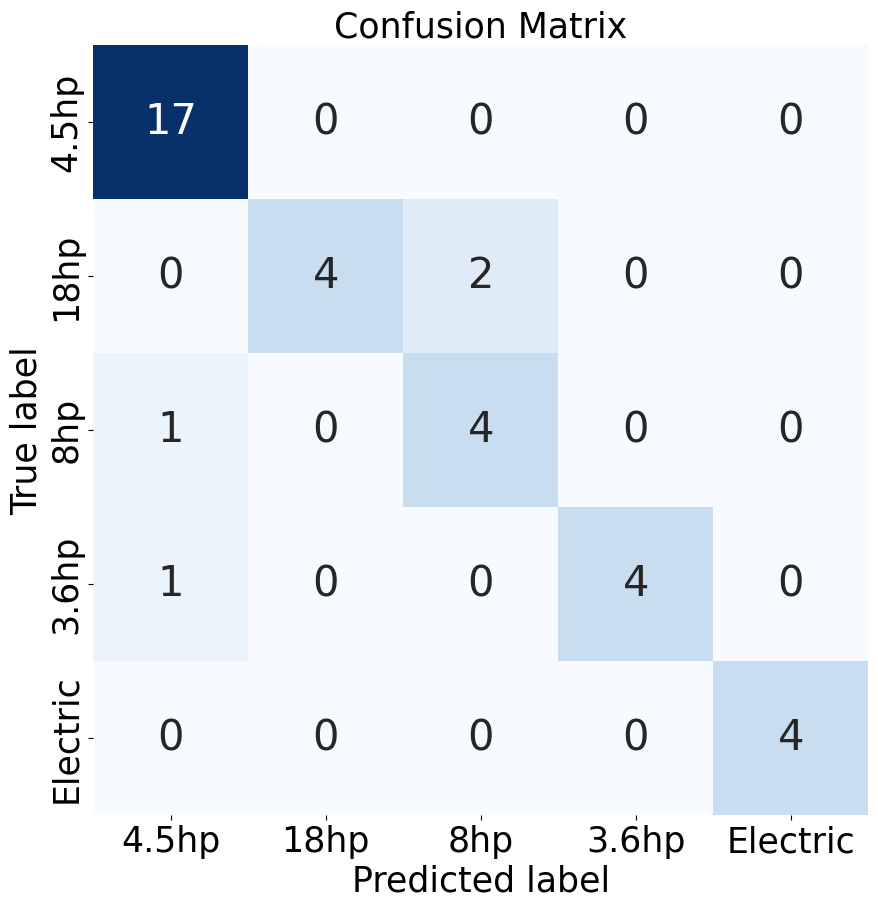

In [17]:
# label catrogories
import json
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/1:1_Arjan_Walia/Vessels")
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
LABEL_METADATA_PATH = ARTIFACT_DIR / "label_metadata.json"
label_metadata = json.loads(LABEL_METADATA_PATH.read_text())
label_cat = label_metadata["class_names"]

#getting evaulations
plot_confusion_matrix(y_true, y_pred, label_cat, text_fontsize=30, xlabel_fontsize=25, ylabel_fontsize=25, xtick_labelsize=25, ytick_labelsize=25, title_fontsize=25)

In [ ]:
#classification reports
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           1       0.89      1.00      0.94        17
           2       1.00      0.67      0.80         6
           3       0.67      0.80      0.73         5
           4       1.00      0.80      0.89         5
           5       1.00      1.00      1.00         4

    accuracy                           0.89        37
   macro avg       0.91      0.85      0.87        37
weighted avg       0.91      0.89      0.89        37



Confusion Matrix for Logistic Regression:


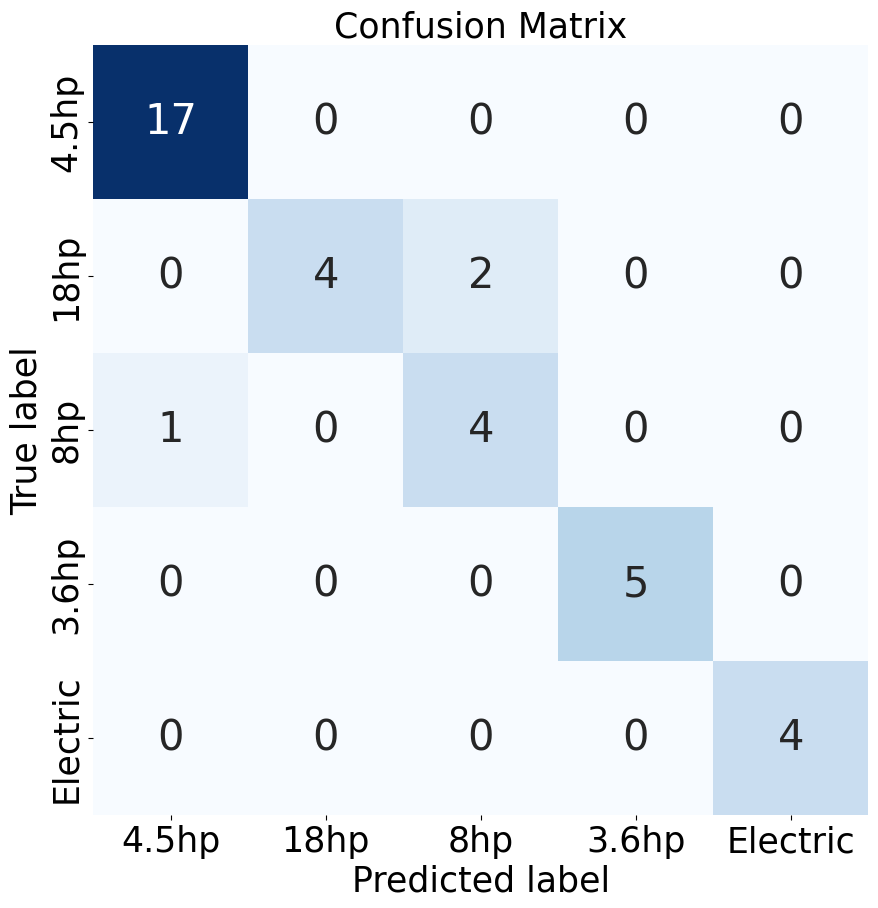

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           1       0.94      1.00      0.97        17
           2       1.00      0.67      0.80         6
           3       0.67      0.80      0.73         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         4

    accuracy                           0.92        37
   macro avg       0.92      0.89      0.90        37
weighted avg       0.93      0.92      0.92        37



In [18]:
model_path_lr = '/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/models/LogisticRegression_bestmodel_OS.pkl'
model_lr = joblib.load(model_path_lr)

y_pred_lr = []

for rows in test_data_list:
  prediction_lr = model_lr.predict(np.array([rows]))
  y_pred_lr.append(prediction_lr[0])

print("Confusion Matrix for Logistic Regression:")
plot_confusion_matrix(y_true, y_pred_lr, label_cat, text_fontsize=30, xlabel_fontsize=25, ylabel_fontsize=25, xtick_labelsize=25, ytick_labelsize=25, title_fontsize=25)

print("Classification Report for Logistic Regression:")
print(classification_report(y_true, y_pred_lr))

Confusion Matrix for Random Forest:


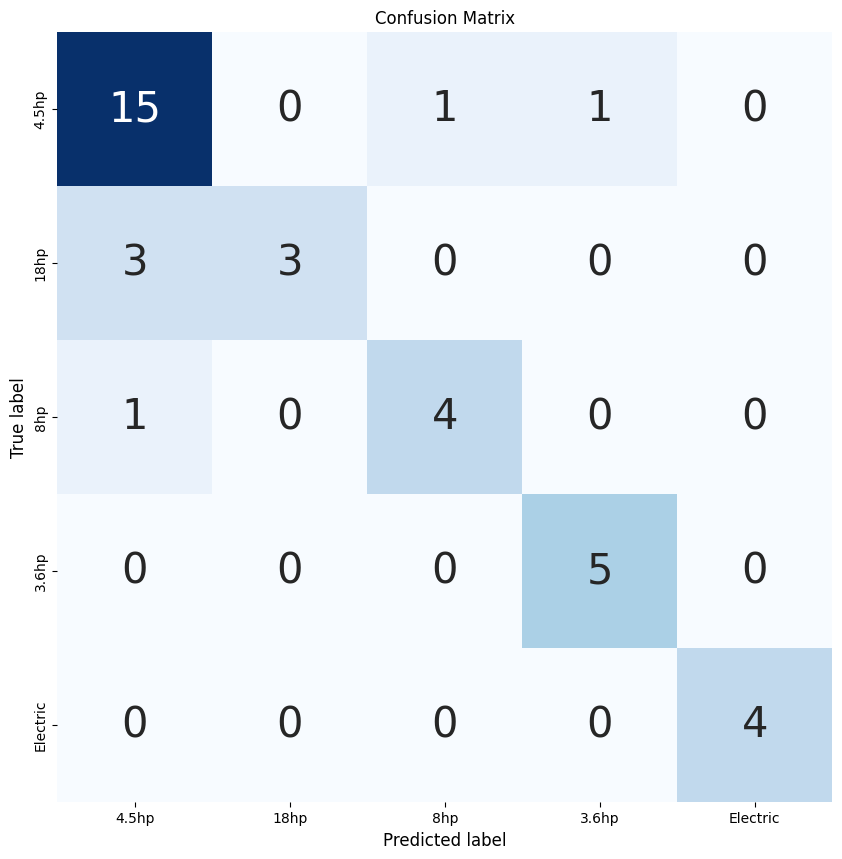

Classification Report for Random Forest:
              precision    recall  f1-score   support

           1       0.79      0.88      0.83        17
           2       1.00      0.50      0.67         6
           3       0.80      0.80      0.80         5
           4       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         4

    accuracy                           0.84        37
   macro avg       0.88      0.84      0.84        37
weighted avg       0.85      0.84      0.83        37



In [19]:
model_path_rf = '/content/drive/MyDrive/1:1_Arjan_Walia/Vessels/models/RandomForest_bestmodel_OS.pkl'
model_rf = joblib.load(model_path_rf)

y_pred_rf = []

for rows in test_data_list:
  prediction_rf = model_rf.predict(np.array([rows]))
  y_pred_rf.append(prediction_rf[0])

print("Confusion Matrix for Random Forest:")
plot_confusion_matrix(y_true, y_pred_rf, label_cat)

print("Classification Report for Random Forest:")
print(classification_report(y_true, y_pred_rf))